<a href="https://colab.research.google.com/github/nitagustienpH/Responsi-AI/blob/main/animal_classifier_bernita_agustien_ph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: bernitagustien
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:31<00:00, 23.1MB/s]


In [2]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device Available: ", device)

Device Available:  cpu


In [3]:
image_path = []
labels = []

for i in os.listdir("/content/animal-faces/afhq"):
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path", "labels"])
data_df = data_df.sample(3000)
print(data_df["labels"].unique())
data_df.head()

['cat' 'dog' 'wild']


,image_path,labels
2991,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
8487,/content/animal-faces/afhq/train/dog/pixabay_d...,dog
6935,/content/animal-faces/afhq/train/dog/pixabay_d...,dog
12545,/content/animal-faces/afhq/train/wild/flickr_w...,wild
6320,/content/animal-faces/afhq/train/cat/pixabay_c...,cat


In [4]:
train = data_df.sample(frac = 0.7)
test = data_df.drop(train.index)

val = test.sample(frac = 0.5)
test = test.drop(val.index)

print(train.shape, test.shape, val.shape)

(2100, 2) (450, 2) (450, 2)


In [5]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])

transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [6]:
class CustomImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["image_path"]
        label = self.dataframe.iloc[idx]["labels"]

        img = Image.open(img_path).convert("RGB")
        label = label_encoder.transform([label])[0]

        if self.transform:
            img = self.transform(img)

        return img, label

In [7]:
train_dataset = CustomImageDataset(dataframe=train, transform=transform)
test_dataset = CustomImageDataset(dataframe=test, transform=transform)
val_dataset = CustomImageDataset(dataframe=val, transform=transform)

In [8]:
print(train.iloc[2, 0])

/content/animal-faces/afhq/train/cat/pixabay_cat_000937.jpg


In [9]:
train_dataset.__getitem__(2)

(tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]]]),
 np.int64(0))

In [10]:
label_encoder.inverse_transform([0])

array(['cat'], dtype=object)

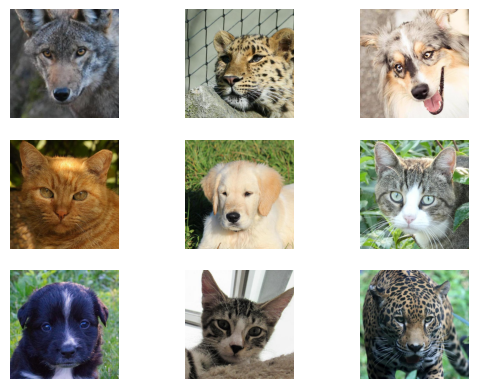

In [11]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = Image.open(data_df.sample(n=1)["image_path"].iloc[0]).convert("RGB")
    axarr[row, col].imshow(image)
    axarr[row, col].axis('off')

In [12]:
LR = 1e-4
BATCH_SIZE = 32
EPOCHS = 6

In [13]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [14]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

    self.pooling = nn.MaxPool2d(2, 2)
    self.relu = nn.ReLU()

    self.dropout = nn.Dropout(0.5)

    self.flatten = nn.Flatten()
    self.linear = nn.Linear((128*8*8), 128)
    self.output = nn.Linear(128, len(data_df['labels'].unique()))

  def forward(self, x):
    x = self.conv1(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.conv2(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.conv3(x)
    x = self.pooling(x)
    x = self.relu(x)

    x = self.dropout(x)

    x = self.flatten(x)
    x = self.linear(x)
    x = self.output(x)

    return x

In [15]:
model = Net().to(device)

In [16]:
from torchsummary import summary
summary(model, input_size = (3,64,64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 64, 64]             896
         MaxPool2d-2           [-1, 32, 32, 32]               0
              ReLU-3           [-1, 32, 32, 32]               0
            Conv2d-4           [-1, 64, 32, 32]          18,496
         MaxPool2d-5           [-1, 64, 16, 16]               0
              ReLU-6           [-1, 64, 16, 16]               0
            Conv2d-7          [-1, 128, 16, 16]          73,856
         MaxPool2d-8            [-1, 128, 8, 8]               0
              ReLU-9            [-1, 128, 8, 8]               0
          Dropout-10            [-1, 128, 8, 8]               0
          Flatten-11                 [-1, 8192]               0
           Linear-12                  [-1, 128]       1,048,704
           Linear-13                    [-1, 3]             387
Total params: 1,142,339
Trainable param

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-5)

In [18]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  model.train()

  for inputs, labels in train_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    optimizer.zero_grad()
    outputs = model(inputs)

    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()

    train_loss.backward()
    optimizer.step()

    train_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
    total_acc_train += train_acc

  model.eval()

  with torch.no_grad():
    for inputs, labels in val_loader:
      inputs, labels = inputs.to(device), labels.to(device)

      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis=1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(total_loss_train)
  total_loss_validation_plot.append(total_loss_val)

  total_acc_train_plot.append((total_acc_train/train_dataset.__len__()) * 100)
  total_acc_validation_plot.append((total_acc_val/val_dataset.__len__()) * 100)

  print(f'''Epoch {epoch +1}/{EPOCHS},
Train Loss: {total_loss_train:.4f} Accuracy: {(total_acc_train/train_dataset.__len__())*100:.2f}
Val Loss: {total_loss_val:.4f} Accuracy: {(total_acc_val/val_dataset.__len__())*100:.2f}
''')

Epoch 1/6,
Train Loss: 70.4538 Accuracy: 43.33
Val Loss: 15.5590 Accuracy: 40.22

Epoch 2/6,
Train Loss: 60.1273 Accuracy: 58.52
Val Loss: 12.6920 Accuracy: 59.56

Epoch 3/6,
Train Loss: 49.7985 Accuracy: 67.52
Val Loss: 10.2931 Accuracy: 73.33

Epoch 4/6,
Train Loss: 41.7068 Accuracy: 74.57
Val Loss: 8.3236 Accuracy: 76.44

Epoch 5/6,
Train Loss: 34.4790 Accuracy: 79.62
Val Loss: 7.0266 Accuracy: 82.00

Epoch 6/6,
Train Loss: 32.4259 Accuracy: 80.52
Val Loss: 6.6300 Accuracy: 83.11



In [19]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0

  for inputs, labels in test_loader:
    inputs, labels = inputs.to(device), labels.to(device)

    predictions = model(inputs)

    acc = (torch.argmax(predictions, axis=1) == labels).sum().item()
    total_acc_test += acc

    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()

print(f"Accuracy: {(total_acc_test/test_dataset.__len__())*100:.2f}%, Loss: {total_loss_test:.4f}")

Accuracy: 78.89%, Loss: 7.6101


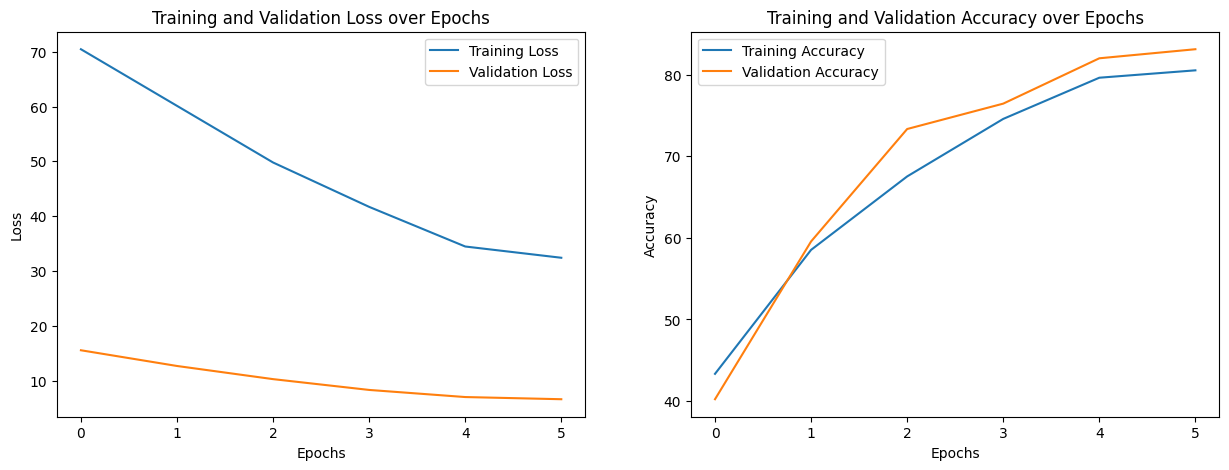

In [20]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_plot, label = 'Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.show()

In [31]:
def predict_image(image_path):
  image = Image.open(image_path).convert('RGB')
  image = transform(image).to(device)

  model.eval()
  with torch.no_grad():
    output = model(image.unsqueeze(0))

  print("Raw output:", output)

  output = torch.argmax(output, axis=1).item()
  return label_encoder.inverse_transform([output])

In [32]:
predict_image("/content/cat1.jpg")

Raw output: tensor([[ 2.9490, -0.9185, -1.3397]])


array(['cat'], dtype=object)